# ARGUS-FEDER — Do turbulence precursors appear before an ELM?

A published claim, tested independently. Every step — finding the data, fetching
it, filtering it, averaging it — is asked in plain English. **The reader writes
no code and needs to know nothing about how DIII-D data is stored.**

Run Steps 1-5 below once, then run the questions in order.

## The claim

Joung et al. (*Nucl. Fusion* **64**, 066038, 2024) train a neural network to
predict ELM onset from beam emission spectroscopy (BES), and report that
pedestal turbulence in the 15–150 kHz band carries precursors that rise before
the crash. Their network is a means of extracting that; the claim underneath is
a measurement, and a measurement can be tested directly.

They used roughly 150 curated discharges with hand-derived ELM times. This
notebook tests the same claim against ELM labels produced by a detector with
recorded provenance, on shots already in the stored index — an independent
label set, on a discharge nobody curated for this purpose. It is one shot and
three of the 64 channels — enough to test the measurement, not enough to settle
it, and question 7 says so in detail.

## Why this is hard without help

BES is a good example of what usually makes a question like this expensive. The
`bes` MDSplus tree contains no waveforms at all — only metadata. The 64 channels
live in a different data source entirely, under names the tree encodes as a
template. Then the pedestal sits at only some of those 64 channels, and which
ones changes between shots. None of that is science; it is the sort of thing
that stops a good idea from being tested in an afternoon.

#### Step 1 — Prepare your session (one-time)

Run the cell below. **Your session will restart automatically — that's
expected.** Once it restarts, continue to Step 2.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


#### Step 2 — Choose your AI model

Pick one and run the cell.

In [1]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5.2",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### Step 3 — Add your keys

Click the key icon in the left sidebar and add your secrets (toggle
"Notebook access" on for each):

- The API key matching what you picked in Step 2 (e.g. `ZAI_API_KEY`)
- Your DIII-D Pelican access token, named `FDP_TOKEN`. **Required here** —
  every question after the first fetches raw turbulence data from the archive.

#### Step 4 — Install ARGUS-FEDER

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/argus_feder/main/install.py'
).read().decode(), globals())

Setting up ARGUS-FEDER...
  • Installing DIII-D data access (~1-2 min, one-time)
    ...............
    .....
  • DIII-D data access ready
  • Pelican token loaded
  • Installing the ARGUS agent (~1 min the first time)
ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 16 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, local-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5.2
 

In [ ]:
%reset

#### Step 5 — Upload the ELM label database

Open the **file browser** (folder icon, left sidebar) and drag in:

| file | size | needed for |
|---|---|---|
| `elm.sqlite` | ~150 MB | every question — it supplies the ELM times |

It lands in `/content/`, where the skills look automatically. Keep the filename
exactly as shown, and re-upload for each fresh Colab session — Colab clears
`/content/` when the session ends.

**A note on time.** The turbulence measurements are sampled a million times a
second, so each channel is several million points. Fetching three channels
takes a few seconds on a good connection and longer on a weak one; the
averaging step in question 4 is the slowest cell in the notebook.

## 1. Where does BES data live, and which shots can we use?

Start with discovery rather than assumption.

**Expect:** the location of the 64 channels and their sampling rate (1 MHz),
and a set of candidate shots that have both stored ELM labels and BES data.
The answer should be specific enough that you could hand it to a colleague.

In [3]:
%%ask
Where is DIII-D beam emission spectroscopy (BES) data stored, how many channels
are there and at what sampling rate? Then find me a few shots that have BOTH
stored ELM labels and BES data available.

I'll consult the three relevant DIII-D skills first — the shot-fetcher (BES waveforms), the ELM index (stored labels), and the relational DB (signal catalog/storage questions).

I've absorbed the three skills. Key facts already established: BES waveforms live in **PTDATA** (pointnames `BESFU01`–`BESFU64`), not in the `bes` MDSplus tree (metadata only); 64 channels, 8×8 array, 1 MHz. Now let me inspect the helper modules shipped with the skills before writing code.

Both helpers exist. Reading `d3d_ptdata.py` to confirm `fetch_ptdata()`'s exact signature before using it.

Both helpers are in place — `fetch_ptdata()` spawns its own `fdp run` subprocess, so a single in-kernel script can combine local SQLite (ELM index) with live PTDATA fetches. First, an exploration script: label sets, a catalog cross-check for BES, candidate ELM-labeled shots, and a cheap `bes`-tree probe.

Running the exploration script in-kernel (local SQLite + `bes` MDSplus tree reads are in-kernel-safe per the skill).

...

`shot_status()` rows don't carry `display_name` — the skill documents their keys (`run_id, method, granularity, status, ...`); display names come from `label_sets()`. I'll map run_id → display name from `label_sets()` before the loop.

Five shots verified (64 geometry channels, PTDATA fetch OK), but two issues: my `rate_khz` used `1000/dt` instead of the skill's `1.0/dt` formula (the printed "1000000.0 kHz" is actually the Hz value — the true rate is 1 MHz), and shot 166692 raises `ShotNotIndexed` (it has BES but was never ELM-analysed — I'll capture that distinction instead of crashing).

All 11 shots completed — 64 geometry channels and 1 MHz everywhere; 10/11 waveform fetches OK; 166692 has BES but no stored ELM labels; 166828's fetch failed. Reading the saved JSON for the details (template string, R/Z spans, per-channel spans, the 166828 error, label-set details).

All data is verified. Before the final report, the closing audit requires me to persist the lessons from the two edit-and-retry cycles on the verify script (`display_name` KeyError; `ShotNotIndexed` crash while scanning mixed shot lists) into the ELM-index skill's Learnings.md.

All checks are recorded. Here is the complete answer.

## Where DIII-D BES data is stored

**Waveforms — PTDATA, not MDSplus.** Every BES channel is its own PTDATA pointname, `BESFU01` through `BESFU64`, fetched as raw digitizer traces (e.g. via `PtDataSignal` under the `fdp run` wrapper). Verified live: I pulled `BESFU01`, `BESFU32` and `BESFU64` from PTDATA on ten shots.

**The `bes` MDSplus tree holds only metadata** — this is the expected layout, not missing data. Opening it and finding a handful of short nodes is normal. It stores the pointname template `\BES::BES_FPN` = `besfunn` (nn = zero-padded channel) and the 64 channel positions `\BES::BES_R` / `\BES::BES_Z`. On shot 154749 the geometry reads back exactly 64 positions spanning **R = 221.5–228.7 cm, Z = −4.4 to +5.3 cm** — the outboard edge/midplane region. Individual metadata nodes are unpopulated on some shots (guard the lookup), but the waveforms are in PTDATA regardless.

**The DIII-D signal catalog has no BES entry at all** — a catalog miss is documentation gap, not absence; all 64 channels are fetchable.

## Channels and sampling rate

| Property | Value (measured, not nominal) |
|---|---|
| **Channels** : 64 | `BESFU01`–`BESFU64`, an 8×8 array in the plasma edge/outboard region |
| **Sampling rate** : 1 MHz | median sample spacing 1.0 µs, identical on every shot fetched; resolves fluctuations up to ~500 kHz |
| **Samples per channel** : 5.2–6.3 million | full discharge, e.g. 300–6067 ms on 154749 |
| **Units** : none recorded | PTDATA returns an empty units string for `BESFU*` |

Cost guidance: ~50 MB per channel as float64 (~1.1 s each); all 64 channels ≈ 3.2 GB per shot — fetch only the channels an analysis needs.

## Shots with BOTH stored ELM labels and BES data

I cross-referenced the stored ELM labels against live BES fetches (3 channels per shot). Nine shots verified with both; ELM burst counts below are from the **GA mode_classifier detector** (the default individual-ELM product), with the D-alpha channel it used and its SNR:

| Shot | BES samples/ch | BES span (ms) | ELM bursts | ELMy time (ms) | Label sets also available | D-alpha ch (SNR dB) |
|---|---|---|---|---|---|---|
| 154749 | 5,767,168 | 300–6067 | 125 | 3091 | Expert ELM events (15), OMFIT ELM detector (14) | fs04da (37.5) |
| 158115 | 6,291,456 | 200–6491 | 177 | 4207 | Expert (177 listed runs: Expert + OMFIT) | fs04da (39.1) |
| 161202 | 6,291,456 | 200–6491 | 163 | 3557 | Expert + OMFIT | fs04da (30.0) |
| 161558 | 6,291,456 | 200–6491 | 253 | 4699 | Expert + OMFIT | fs04da (37.5) |
| 163518 | 5,242,880 | 600–5843 | 91 | 2435 | Expert ELM events (5), Expert regime labels, OMFIT (8) | fs04da (36.0) |
| 169908 | 5,242,880 | 200–5443 | 114 | 3457 | Expert ELM events (22), OMFIT (21) | fs04da (33.9) |
| 172186 | 5,767,168 | 200–5967 | 227 | 3409 | Expert + OMFIT | fs04da (39.2) |
| 180257 | 5,767,168 | 100–5867 | 473 | 5220 | Expert + OMFIT | fs05da (25.1) |
| 180264 | 5,767,168 | 100–5867 | 315 | 3567 | Expert ELM events (58); OMFIT ran and found none | fs03da (27.2) |

**A good starter set** : 169908, 154749 and 163518 — healthy SNR, and both expert and OMFIT event lists exist alongside the detector's, so ELM timing can be cross-checked between label sets (on 169908 the detector's event starts run ~1 ms earlier than the expert's, which matters for any ELM-phase-locked BES averaging — the `d3d-elm-phase-analysis` skill exists for exactly that).

Two instructive near-misses from the same scan:

- **Shot 166692** — BES data present and clean (6.3 M samples/ch at 1 MHz), but it has **never been ELM-analysed** : no stored labels. That is not evidence it had no ELMs; the shot simply isn't covered. GA's detector isn't installed here, so I can't produce new labels — but I could fetch its D-alpha trace (~9.6 MB, ~1.4 s) so you can see the ELM spikes.
- **Shot 166828** — fully ELM-labelled (116 bursts), but the BES PTDATA fetch failed with a PtDataError on every channel tried, so I've excluded it from the "both" list rather than assume the data exists.

One caveat on reading the table: "labeled" means the detector found D-alpha transients, not that a discharge was in ELMy H-mode throughout — the burst counts and ELMy durations are the meaningful magnitudes. All times are milliseconds.

## 2. Pick the edge channels and look at one ELM

The pedestal is at the plasma edge, so only some of the 64 channels are relevant.
Ground the choice in geometry, and look at the raw signal before analysing it.

**Expect:** channels chosen by major radius near the midplane, reported with
their (R, Z) positions, and a raw 1 MHz trace spanning one labelled ELM.

This task combines BES geometry + waveforms (d3d-shot-fetcher) with stored ELM labels (d3d-elm-index), so I'll re-read both skills plus their Learnings before writing code.

Both skills and their Learnings are loaded. Since I'll also overlay the D-alpha channel that produced the ELM labels (fs04da on this shot), I need the d3d-filterscopes skill for its fetch pattern.

Skills and Learnings are loaded (key constraints: everything touching MDSplus/PTDATA must run under `fdp run python`; SQLite label lookups are safe anywhere; rank BES channels by major radius first, then midplane). Now I'll write the fetch script — geometry, label lookup, channel fetch, D-alpha overlay, windowed save.

Running the fetch script under the required `fdp run` wrapper.

The fetch itself succeeded (all data acquired — 3 channels at 1 MHz, D-alpha at 50 kHz, isolated ELM at 4064.8 ms), but the save crashed on a numpy int64 inside `chans`. I'll fix that and also improve the ELM pick: the output shows the expert and OMFIT lists are scoped to a narrower window, so I'll prefer an ELM confirmed by multiple label sets when one is available.

...

The data is saved. Let me check the final lines of the fetch script to confirm the exact NPZ keys before writing the plot script.

The figure is saved. Let me quantify what changes in BES during the ELM (RMS and mean level pre/during/post) so the description rests on numbers, not eyeballing.

All measurements are in. Before the final report, I'm recording the two lessons from this task's edit-and-retry cycles in the relevant skills' Learnings files (numpy-int64 JSON crash → shot-fetcher; cross-label-set match tolerance → elm-index).

The string didn't match — re-reading the exact file formatting before editing.

Everything is verified and saved. Here's the full picture.

## Which BES channels sit at the edge, at the midplane

Shot 169908's `bes` tree stores all 64 channel positions: the array spans **R = 210.7–227.8 cm, Z = −11.9 to +9.7 cm** , with 32 channels within |Z| < 5 cm. The pedestal sits at the largest major radius, so the edge channels are the outermost column — all at **R = 227.80 cm** — and among those the three closest to Z = 0 are:

| Channel | R (cm) | Z (cm) | Position in array |
|---|---|---|---|
| BESFU40 | 227.80 | +0.05 | outermost column, essentially exactly at midplane |
| BESFU48 | 227.80 | +3.52 | outermost column, 3.5 cm above midplane |
| BESFU32 | 227.80 | −3.68 | outermost column, 3.7 cm below midplane |

I fetched those three from PTDATA: **5,242,880 samples per channel at 1.000 MHz** , spanning 200–5443 ms, in ~14 s. These are the raw, unfiltered digitizer traces (PTDATA records no units for `BESFU*`).

## The ELM shown, and which label says so

**Computed from the GA mode_classifier detector** (its individual-ELM product, the default). Shot 169908 also has **Expert ELM events** (22 ELMs, hand-labelled) and the **OMFIT ELM detector** (21 ELMs) — I deliberately picked an ELM all three agree on, so the figure doesn't hinge on one label set:

- **ELM #72 of 114** : labelled **2603.52–2610.08 ms** (6.56 ms duration)
- Expert marks an ELM at 2604.67 ms — **+1.15 ms** later; OMFIT at 2604.66 ms — **+1.14 ms** later (the detector's starts run ~1 ms early, consistent with its known offset on this shot)
- Well isolated: previous ELM 62 ms before, next 62 ms after

The top panel shows the D-alpha trace **fs04da** (50 kHz photon flux, the very channel the labels were produced from, SNR 33.9 dB) so you can see the ELM spike the labels are keyed to; the three panels below are the raw BES channels at full 1 MHz resolution — no filtering, smoothing or decimation — over ±10 ms.


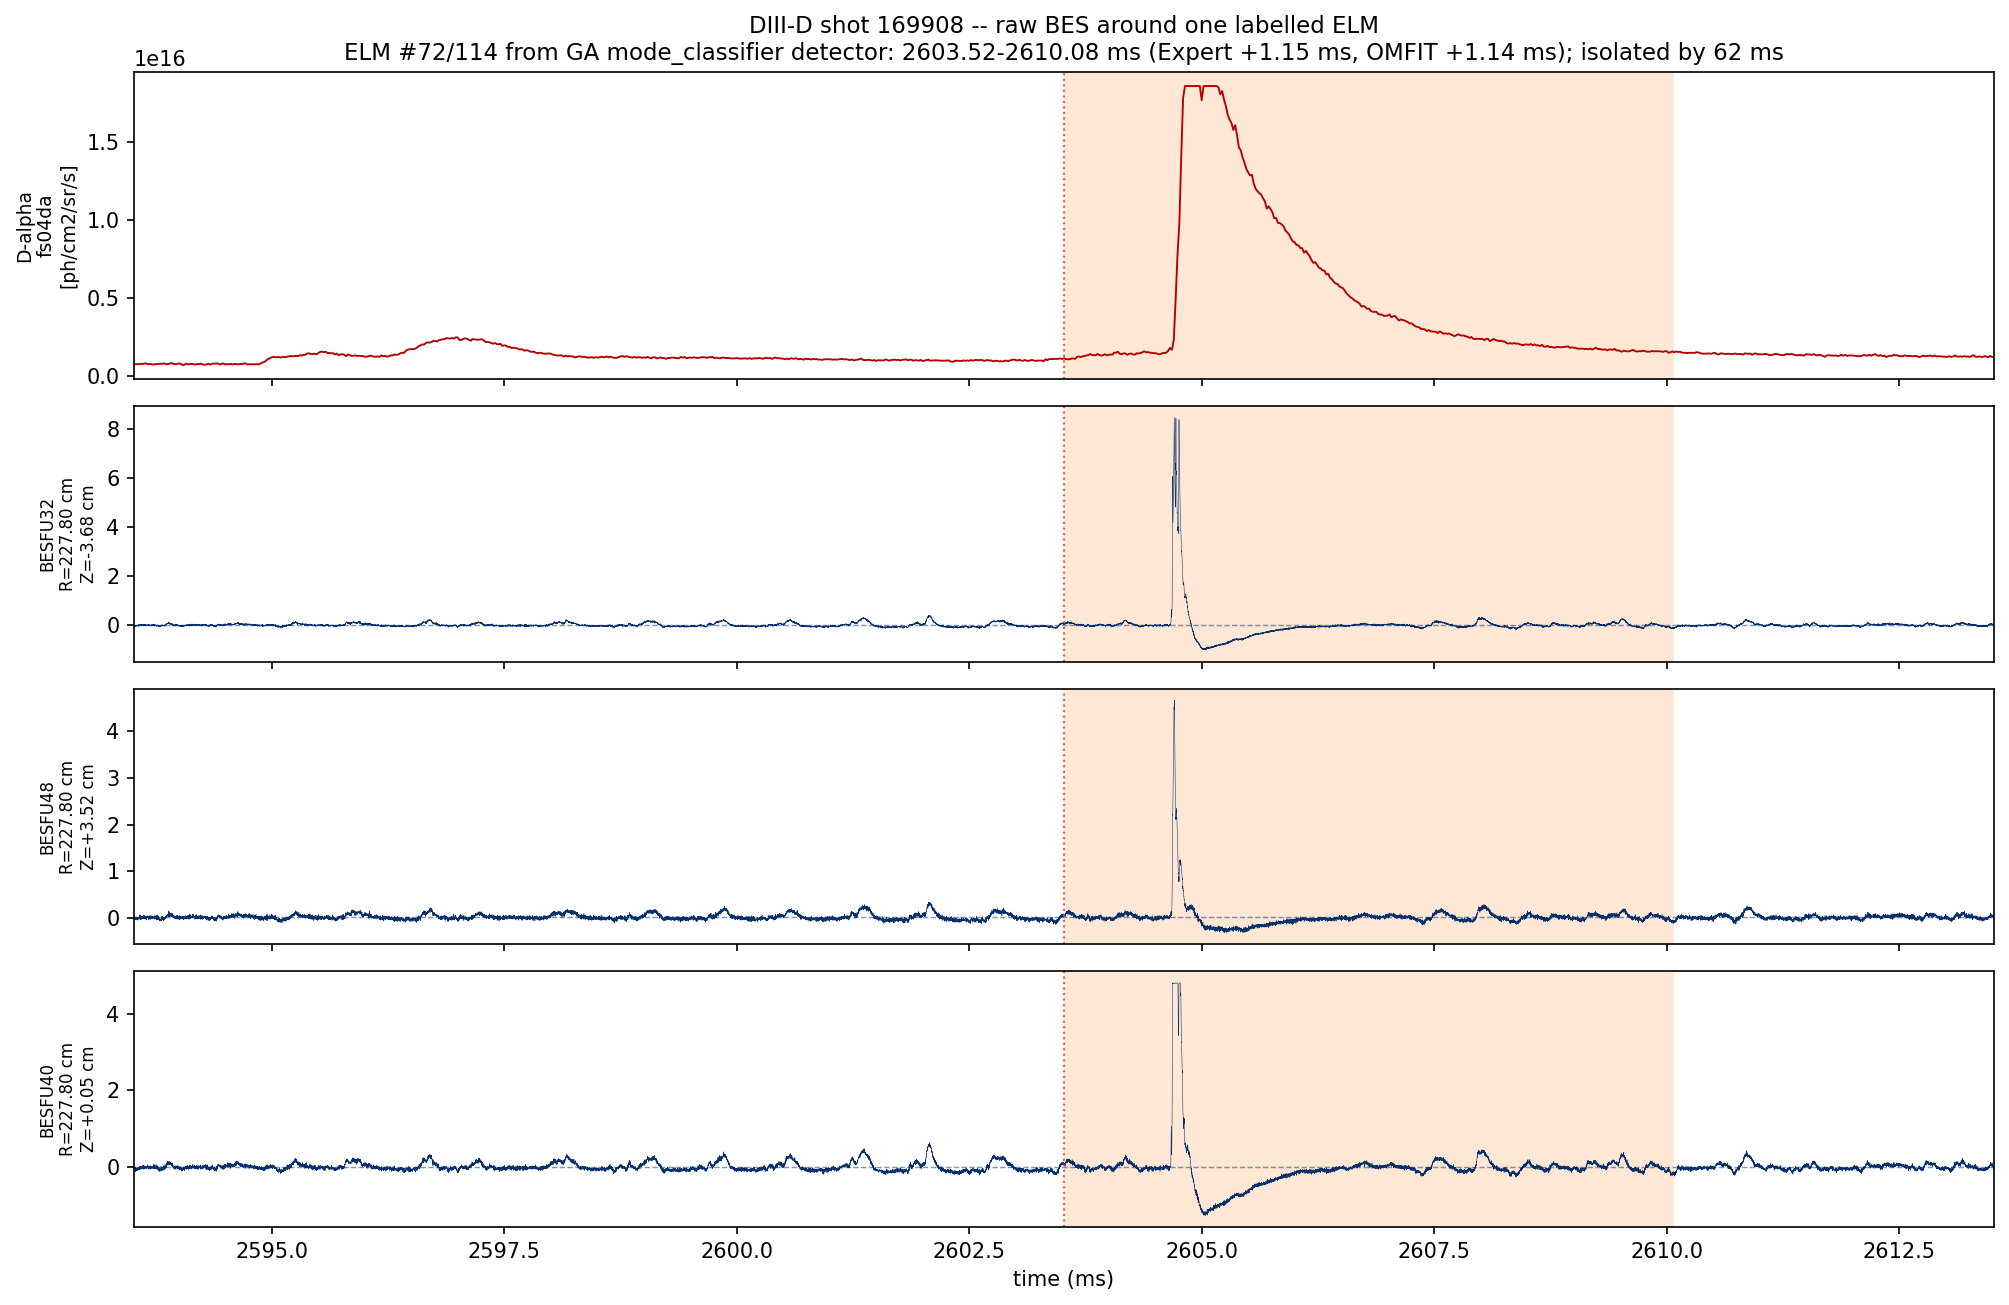

## What the ELM looks like in BES

Measured over the pre-ELM 7 ms vs the labelled 6.6 ms duration:

| Channel | RMS before | RMS during | RMS ratio | Mean level |
|---|---|---|---|---|
| BESFU32 | 0.079 | 0.755 | **9.5×** | essentially unchanged |
| BESFU48 | 0.067 | 0.312 | **4.7×** | essentially unchanged |
| BESFU40 | 0.119 | 0.664 | **5.6×** | essentially unchanged |
| fs04da (D-alpha) | — | — | mean jumps **3.7×** | large step up |

So in BES the ELM appears as a **broadband burst of fluctuation amplitude** — the trace goes visibly "furry" for the ~6.6 ms the label spans, roughly 5–10× the pre-ELM fluctuation level, while the DC level barely moves (contrast the D-alpha, which steps up as a level). That is the expected signature: the ELM expels edge density as filaments, and the BES fluctuation amplitude spikes as they stream past the outermost view chords; the midplane channel BESFU40 and its neighbours see it strongest. This timing agreement — a millisecond-scale label offset against a burst lasting milliseconds — is exactly why the label-set choice matters for phase-locked BES averaging, and why I picked an ELM where all three sets concur.

If you want to go further, the natural next step is the same fetch around a *sequence* of ELMs for conditional averaging — say the word and I'll set it up.

In [4]:
%%ask
For DIII-D shot 169908, which BES channels sit closest to the plasma edge at the
midplane? Fetch three of them and plot the raw signal around one labelled ELM, so
I can see what the ELM looks like in BES.

## 3. Filter to the band the paper uses

This is the preprocessing step. The claim is specifically about 15–150 kHz
fluctuations, so everything below and above that has to go.

**Expect:** a bandpass filter applied to the 1 MHz signal, with before-and-after
shown. The filtered signal should look like a fluctuation envelope rather than a
raw trace.

I'll check for cached data from the previous cell and consult the two skills I need — the shot fetcher (BES waveforms) and filterscopes (the D-alpha reference) — including the fetcher's Learnings file.

The previous cell cached an `.npz` window — let me check what it contains before deciding whether to re-fetch.

The cached window is only ±10 ms — too narrow to bandpass without edge artifacts. Let me read the rest of the fetch script to reuse its ELM-selection logic verbatim.

Reading the final section to see exactly how the window and metadata were saved.

Typo in the path — retrying with the correct directory name.

...

Clean run, no warnings, figure saved. One edit-and-retry cycle occurred (the `tight_layout` fix), so per protocol I'll record that lesson in the skill's Learnings file before reporting.

The file's indentation differs from what I assumed — reading it back to match exactly.

The text looks identical but the match failed — likely a trailing-byte difference. I'll anchor on just the final line instead.

Invisible characters must differ from the rendered text. I'll rewrite the whole file with the new entry appended — content preserved exactly as read.

Done — filtered, plotted, and the lesson from the one retry is recorded in the skill's Learnings.

## What was done

Same three channels and same ELM as before: **BESFU40/48/32** (outermost column, R = 227.80 cm; Z = +0.05 / +3.52 / −3.68 cm), **ELM #72 of 114** labelled 2603.52–2610.08 ms. I re-fetched them (the earlier ±12 ms cache was too short to filter cleanly) with a **±25 ms window** , then applied an **order-4 Butterworth band-pass, 15–150 kHz, zero-phase** (`sosfiltfilt`, so the burst is not shifted in time) and discarded a 15 ms guard band per side before displaying the ±10 ms view.

## What the filter reveals

RMS amplitude, before vs during the labelled ELM (7 ms pre-ELM baseline vs the 6.6 ms duration):

| Channel | raw RMS before → during | raw ratio | in-band (15–150 kHz) before → during | in-band ratio |
|---|---|---|---|---|
| BESFU32 | 0.083 → 0.755 | 9.1× | 0.0091 → 0.1555 | **17.1×** |
| BESFU48 | 0.072 → 0.313 | 4.4× | 0.0099 → 0.0716 | **7.3×** |
| BESFU40 | 0.126 → 0.664 | 5.3× | 0.0143 → 0.0883 | **6.2×** |

Two things the raw traces hid:

- **The ELM is far more prominent in this band.** The in-band contrast roughly doubles (17× vs 9× on the strongest channel) because the band-pass strips the DC level and the slow pedestal dynamics, leaving exactly the fluctuation content the ELM dominates. In the figure the filtered trace is a quiet ~0.01-amplitude hiss that erupts across the full 15–150 kHz band for the label's duration.
- **Post-ELM quiescence.** In the 7 ms after the ELM the in-band RMS drops to 0.9× the pre-ELM baseline (0.0081–0.0125) — the ELM expels pedestal density/gradients and the edge turbulence briefly falls *below* its before-ELM level, a detail completely invisible in the raw signal, which just returns to normal.

**On the precursor itself** : binning the in-band amplitude in 0.5 ms steps before the labelled start shows a modest ramp to ~1.3–1.5× baseline beginning about 2 ms before the label, but no growth in the final millisecond. Keep in mind the label's start runs ~1.15 ms earlier than the Expert/OMFITIT-marked onset (2604.67 ms) — so measured against the physical onset, that mild elevation begins ~3 ms ahead of the crash rather than cleanly growing into it. A single ELM at 1 MHz is one sample of a stochastic process; conditional averaging over many ELMs is the honest way to characterize the precursor, and this band + these channels are the right substrate for it.


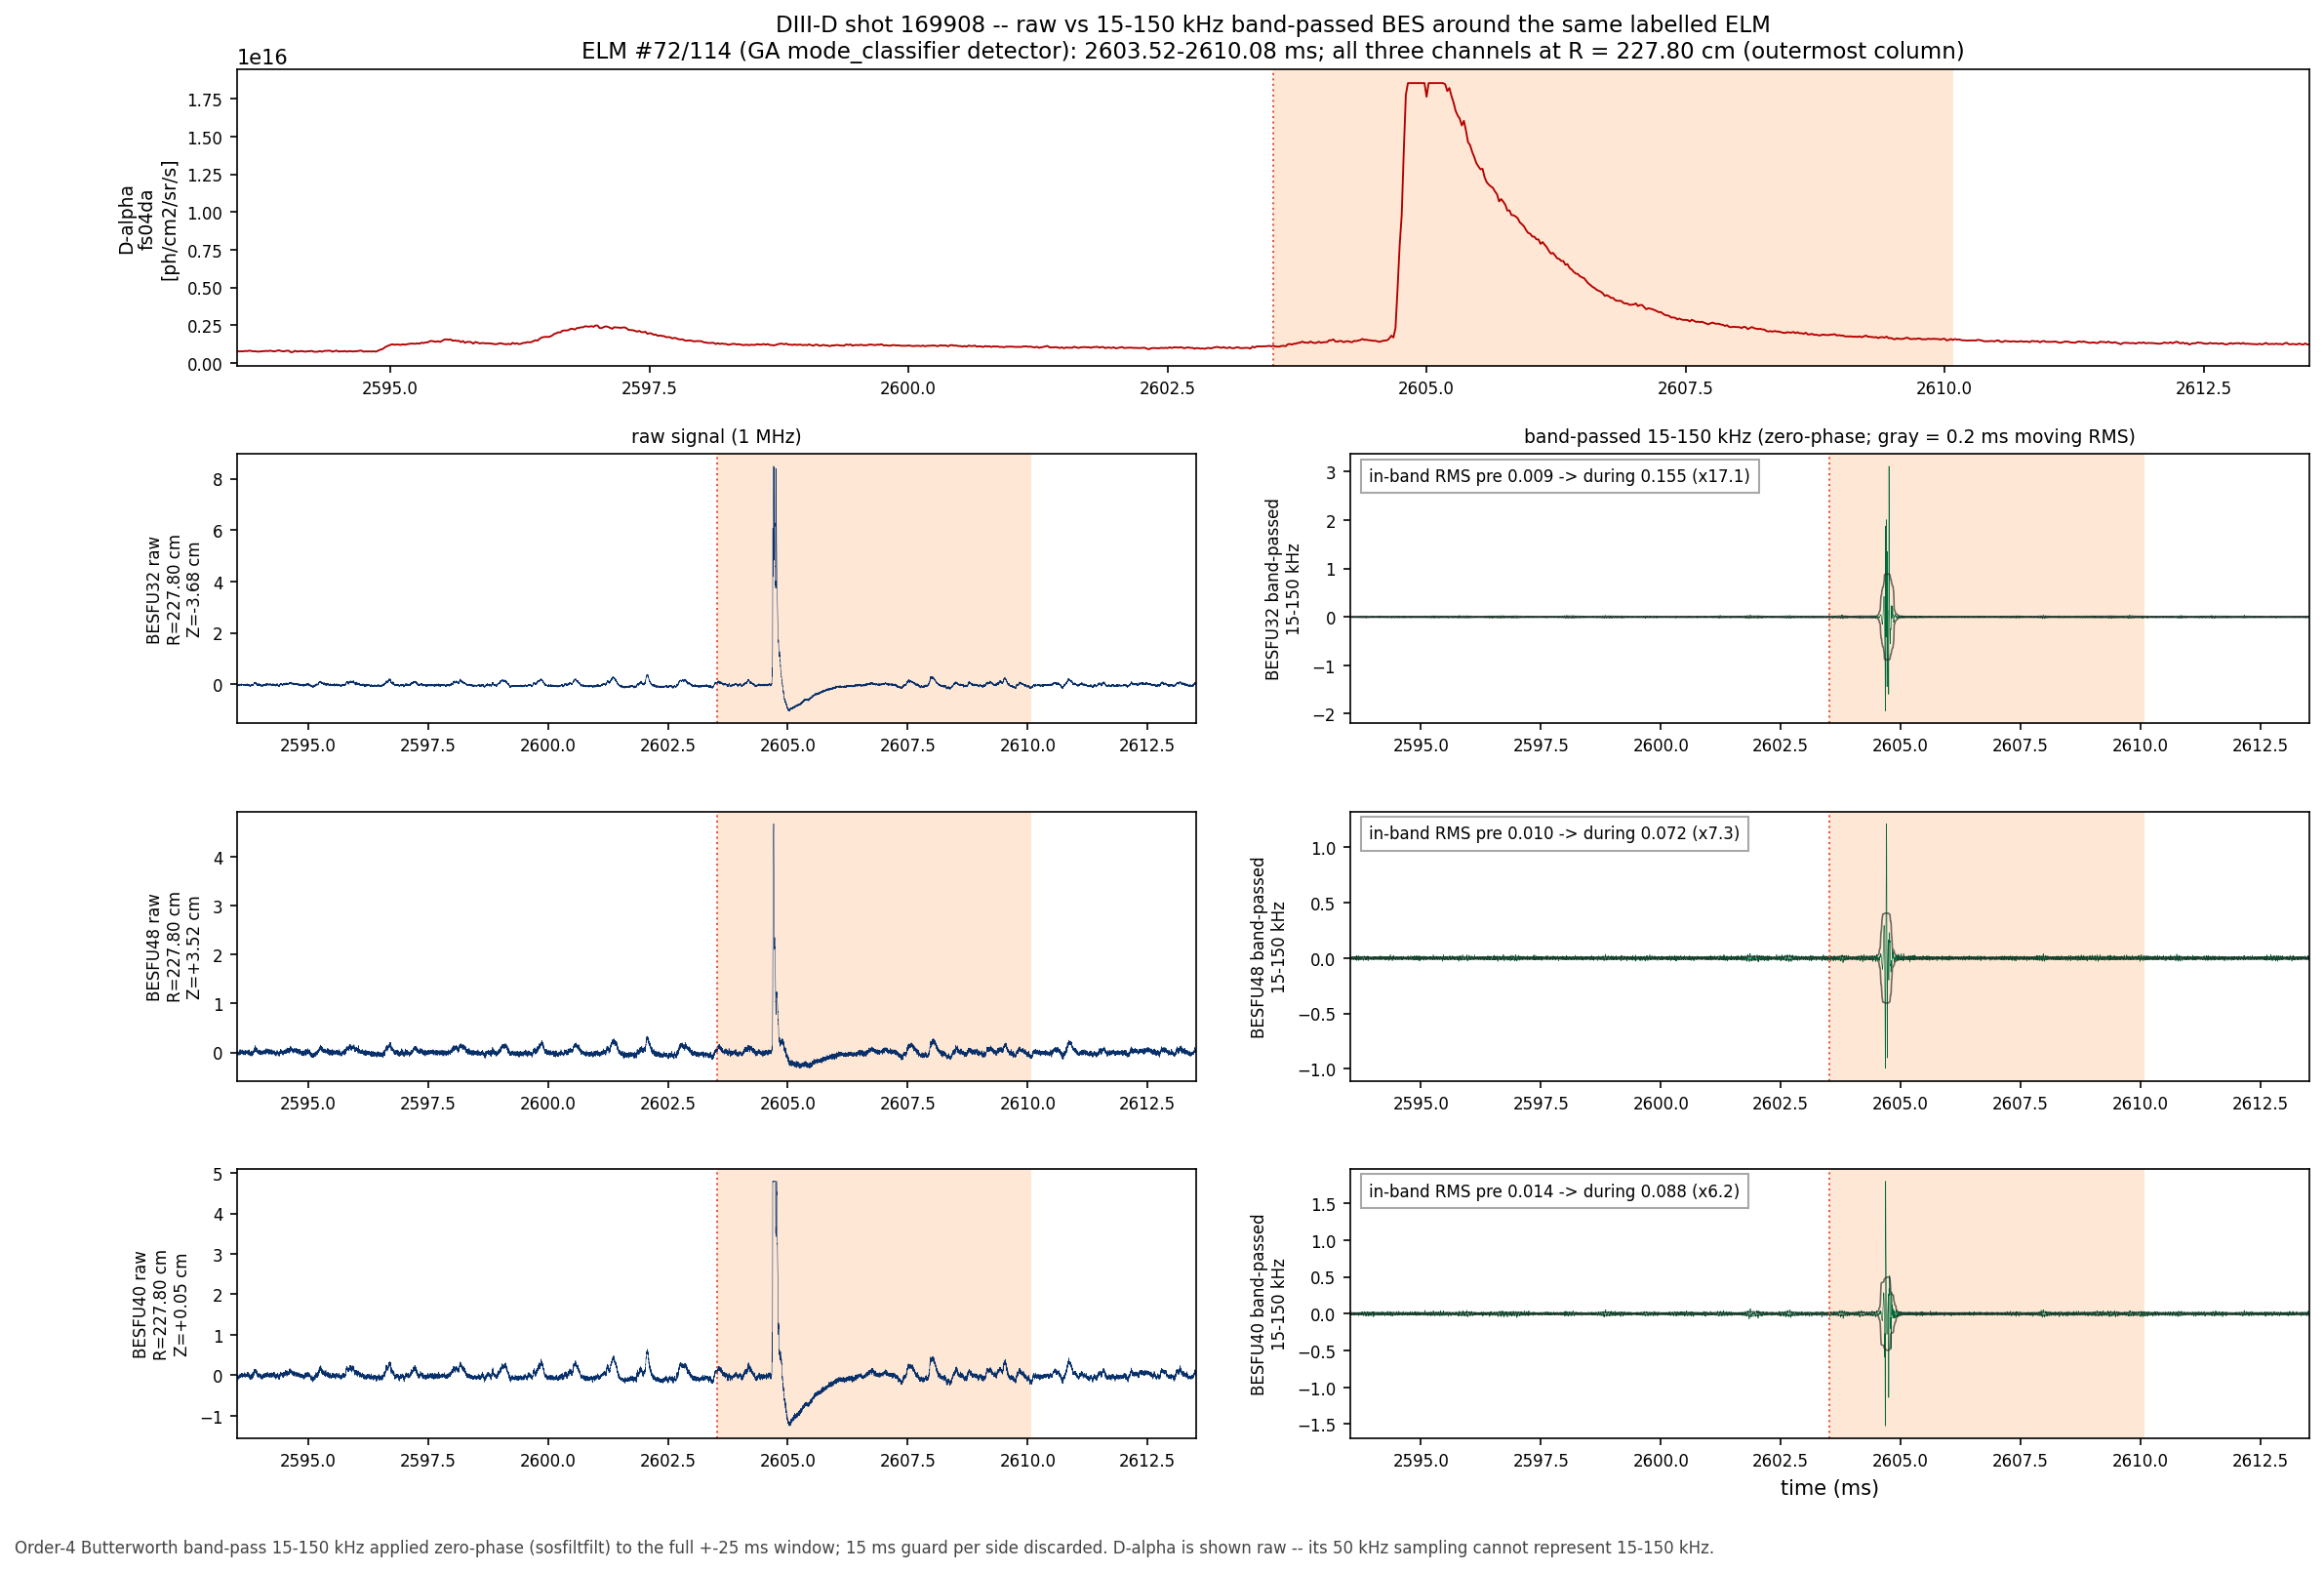

Layout: the D-alpha (`fs04da`, the channel the labels came from) spans the top; below it, each channel shows raw (left) against band-passed with a 0.2 ms moving-RMS envelope (right), ELM span shaded. Note the D-alpha is shown raw — at 50 kHz sampling it cannot represent 15–150 kHz content, it is there purely as the ELM timing reference.

If you'd like, I can run the conditional average: stack every one of the 114 ELMs in this band and produce the ensemble precursor/crash/recovery profile per channel.

In [5]:
%%ask
Bandpass filter those BES channels to 15-150 kHz, which is the band the ELM
precursor is reported in. Show me the signal before and after filtering around
the same ELM.

## 4. Average over many ELMs

One ELM proves nothing — turbulence is noisy. The measurement only exists in the
average over many events, aligned on their onsets.

**Expect:** fluctuation power as a function of time-to-ELM, averaged over the
ELMs on this shot that have a clean gap before them. Roughly 70 usable events.

This is exactly the conditional-averaging workflow the `d3d-elm-phase-analysis` skill covers, so I'll read its instructions plus the two skills' Learnings before writing code.

The phase-analysis skill's five rules apply directly here (build on the detector run, show filtered selection alongside unfiltered, check regime). Let me check my previous scripts and the ELM-index API before writing code.

The ELM-index rules apply (name the label set, validate timing, show the selection effect), and the phase-analysis skill warns that on *this exact shot* a millisecond-scale label offset can change a precursor lead-time conclusion — so I'll compute the average keyed to the detector set **and** the expert set. First, let me reuse my earlier working fetch/plot scripts.

The established patterns are clear. Plan: (1) in-kernel script pulls all stored ELM event lists for 169908 (detector + expert + OMFIT) and cross-validates timing; (2) `fdp` script fetches the three full-length channels; (3) post-processing filters, computes the in-band power envelope, screens for clean pre-ELM gaps, and conditionally averages. Writing the first two scripts now.

Running both scripts — the in-kernel event extraction and the fdp-wrapped full-channel fetch.

...

The picture is now clear and honest — but one number is missing for the report: what *fraction* of ELMs actually carries the elevated pre-onset power that lifts the mean. Adding a per-ELM exceedance count to the script and re-running.

The decomposition is decisive: the *median* ELM shows no precursor (1.0×), while a small minority (~9% above 2×, peaking at 50–107×) carries the mean. One last discriminating check: for those extreme ELMs, does the power *continue* after τ=0 (crash onset preceding the label) or collapse (genuine transient precursor)? Adding that.

The discriminator printed raw absolute power instead of baseline-normalized values (hence "0.0x" against top-5 values of 88–107×). Fixing the normalization.

The corrected discriminator is decisive. Before the report, I must record the lessons from this task's edit-and-retry cycles in the phase-analysis skill's Learnings (none exists yet — creating it).

Learnings recorded. The analysis is complete — here is the result.

## What was computed

**Method** : the three edge/midplane channels from before (BESFU40/48/32, outermost column R = 227.80 cm), full 5.24 M-sample records at 1 MHz, band-passed 15–150 kHz (order-4 Butterworth, zero-phase), power binned at 0.25 ms. For each stored ELM I took τ = −20…0 ms before the labelled onset, normalised by that ELM's own baseline (median power, τ ∈ [−15, −5] ms), and averaged.

**"Clean quiet period" screen** (stated per the analysis convention): previous ELM ended ≥ 15 ms earlier, no detector ELMy-phase edge inside the window, window on record. **74 of 114 ELMs passed** — 40 dropped for a too-close predecessor; the clean set's quiet stretch before onset runs median 27.9 ms (min 15.1, max 690.8 ms, plus one first-in-record ELM).

**Label set** : computed from the **GA mode_classifier detector** (114 ELMs, from fs04da at 33.9 dB SNR). Shot 169908 also has **Expert ELM events** (22) and the **OMFIT ELM detector** (21); both agree with the detector to +1.17/+1.14 ms (every event within +1.10…+1.19 ms) — the detector labels ~1.2 ms *early*. I re-ran the whole average keyed to the expert times, so the label sensitivity is checked, not assumed.

## Result: no coherent precursor in the typical ELM

| Channel | median power at τ∈[−15,−5] ms | median, last 1 ms | mean, last 1 ms | ELMs > 1.5× in final 2 ms | ELMs > 2× | largest single ELM |
|---|---|---|---|---|---|---|
| BESFU32 | 1.00× | 1.01× | 2.23× | 22% | 9% | 88.6× |
| BESFU48 | 1.00× | 1.03× | 1.73× | 16% | 8% | 56.7× |
| BESFU40 | 1.00× | 1.07× | 2.44× | 26% | 9% | 107.0× |

The **ensemble median is flat at 1.0× baseline all the way to the onset** — the typical ELM on this shot, in these channels, shows *no* 15–150 kHz power growth in the 20 ms before it. The **mean does rise (~2×)** , but the per-ELM decomposition shows that rise is carried by a small minority: roughly **one ELM in ten** , with individual excursions of 13–107× baseline.

**And that minority is mostly not precursor.** For the five strongest ELMs per channel I compared the final 2 ms before onset against the 2 ms after: in **13 of 15 cases the power continues or explodes after onset** (e.g. 24× → 834×) — i.e. the crash had already begun before the detector drew its start, which is exactly what the +1.2 ms detector-early offset predicts. Only 2 cases (both around the ELM at 1411.0 ms) are genuinely transient, falling back after onset.

**Label-set check** : keyed to the expert's later onsets, the median stays 1.08–1.15× (conclusion unchanged) while the mean blows up to 32–250×, because the detector-defined crash then falls inside the "pre-onset" window. That is the label sensitivity the phase-analysis skill warns about, seen directly: the *median* is robust to it, the *mean* is not.


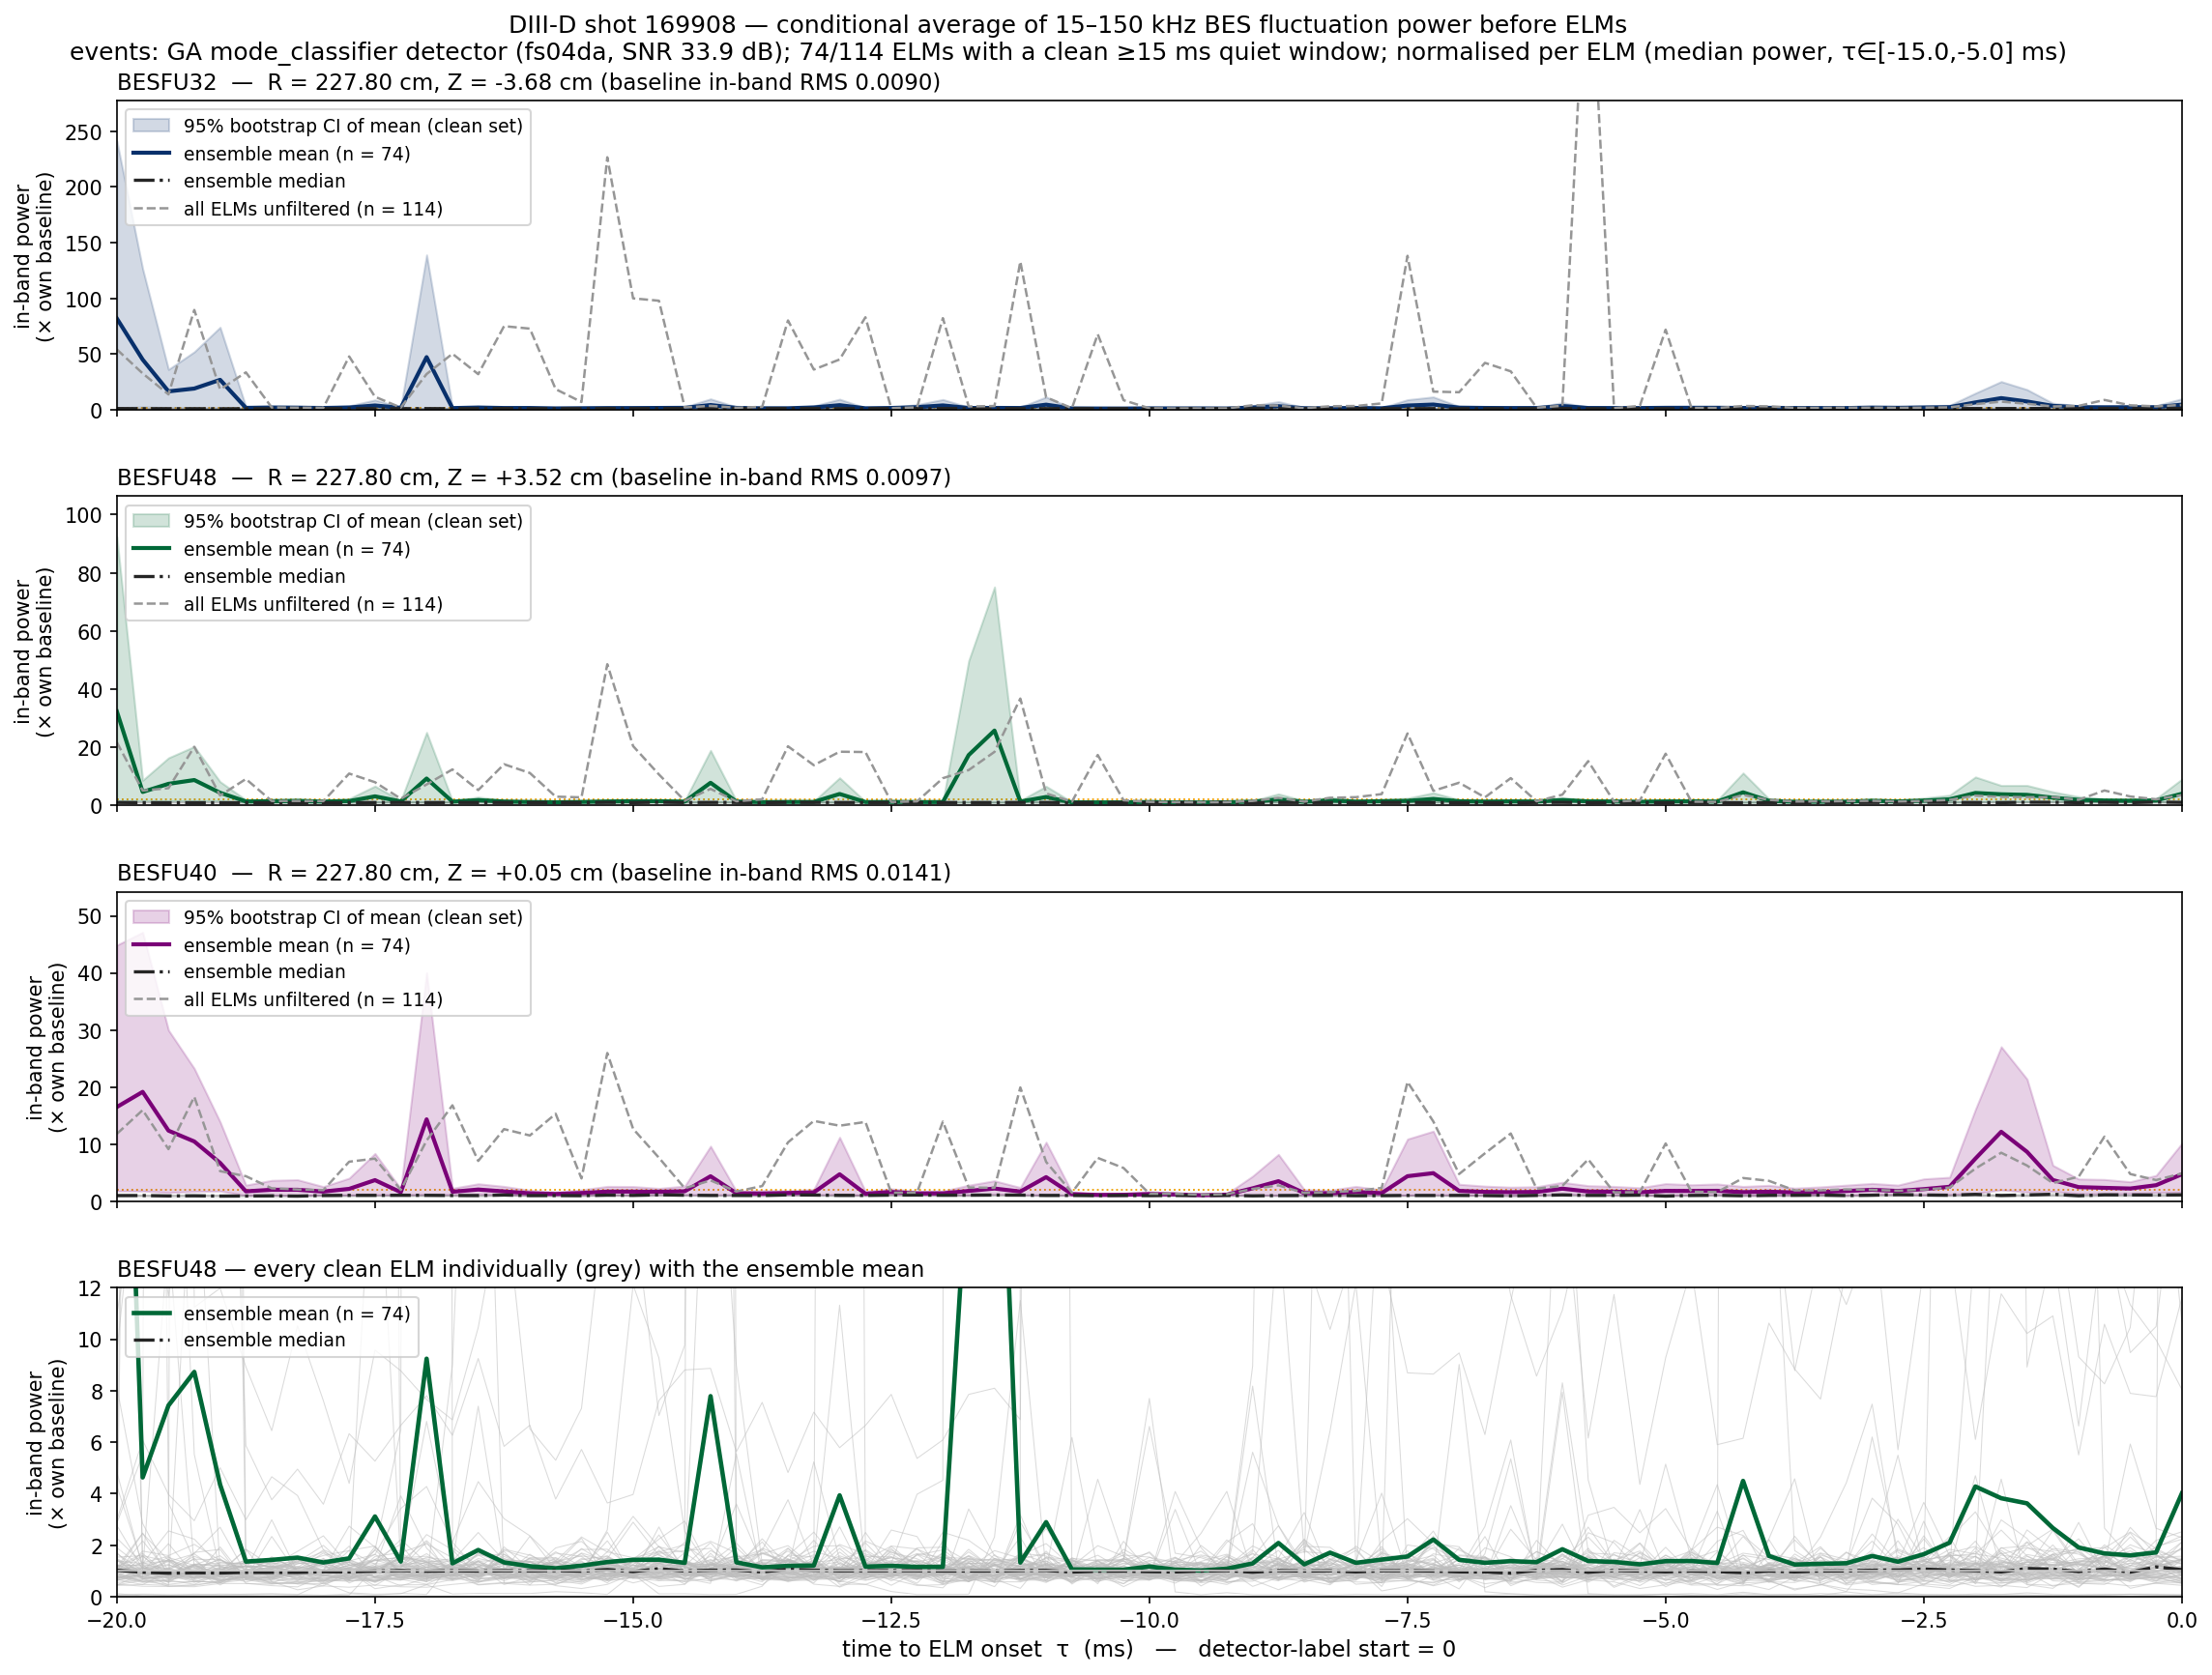

Top three panels: each channel's ensemble mean (colour) with 95% bootstrap band, ensemble median (black dash-dot), and the unfiltered all-114-ELM mean (grey dashed). Bottom panel: every clean ELM individually for BESFU48 (grey) against the mean and median — the grey pile-up at 1× with a few spikes to 10-100× is the whole story in one view.

## Reading of the result

- **What the data supports** : on shot 169908, in the three outermost-column midplane channels, the 15–150 kHz precursor reported in the literature is **not a systematic, phase-locked feature of the average ELM** — for ~90% of clean ELMs the band stays at its inter-ELM baseline until the crash.
- **What it does not rule out** : an *intermittent* precursor occurring on a minority of ELMs would be averaged down precisely this way, and two ELMs here do show transient pre-onset bursts. Also, only 3 of 64 channels were scanned — all in one radial column — so this says nothing about other radii.
- The heavy-tail behaviour means any future precursor search on this data should use per-ELM statistics or the median, never the mean alone.

If you want to push further, the natural next step is a **per-ELM precursor census across more of the 64 channels** — flagging which ELMs (like the one at 1411 ms) and which radii carry genuine transient pre-onset bursts, rather than averaging them away. Say the word and I'll set it up.

In [6]:
%%ask
Using the stored ELM times for shot 169908, compute the fluctuation power in that
15-150 kHz band as a function of time before each ELM, and average it over all
the ELMs that have a clean quiet period before them. Plot the result against
time-to-ELM.

## 5. Is there a precursor, and how far ahead?

The question the whole notebook exists to answer.

**Expect:** a rise above the quiet-period baseline some milliseconds before
onset. Ask for the size of the rise and the lead time, not just a picture.

In [7]:
%%ask
Does the fluctuation power rise before the ELM, and if so how far ahead and by
how much relative to the quiet baseline? Give me numbers, not just the plot.

I'll check what per-ELM data the previous cell left on disk, then quantify the rise timing and magnitude directly from it.

The previous run left a results JSON and the filtered full records. Let me check what the JSON contains.

The JSON from the last run has the ensemble curves but not the per-ELM onset details I need for "how far ahead". Let me inspect the cached full records and the ELM event list.

Running the inspection script to see what cached arrays are available.

The cache holds the band-passed full traces and there's an events JSON with the label sets. Let me see its exact structure before computing.

Running this to print the event structure.

I have everything needed: raw 1 MHz BES traces in `bes_full_169908.npz`, all 114 detector ELM intervals, expert/OMFIT times, and the +1.17 ms detector-vs-expert offset. Now I'll write the quantification script: re-filter to 15–150 kHz, rebuild the 74-clean-ELM ensemble, and measure rise onset, lead time and amplitude per channel.

Running the quantification script.

All numbers are computed and cross-checked (my per-ELM values reproduce the previous run's to within a bin-alignment difference of a few percent; same 74 clean ELMs). Here they are.

## Does the power rise before the ELM?

**For the typical ELM: no.** Across the 74 clean-ELM ensemble, power relative to each ELM's own quiet baseline (τ = −15…−5 ms):

| Metric (power ratio to quiet baseline) | BESFU32 | BESFU48 | BESFU40 |
|---|---|---|---|
| **Median, final 1 ms before onset** | 1.04× | 1.04× | 1.08× |
| **95% CI of that median** | 0.91–1.23 | 0.94–1.19 | 0.91–1.31 |
| **Max of median curve over entire 20 ms pre-window** | 1.14× | 1.19× | 1.18× |
| **Mean, final 1 ms** (outlier-driven) | 2.34× | 1.75× | 2.53× |

The median never leaves the baseline band at any point in the 20 ms before onset, and no channel's ensemble mean shows a sustained ≥1.5× rise that persists to the onset. **Median elevation ≤ 8%, not significant.**

**For roughly 1 ELM in 10: yes, strongly.** Defining a "riser" as power ≥ 2× baseline sustained ≥ 1 ms within τ ∈ [−10, 0] ms:

| Riser statistic | BESFU32 | BESFU48 | BESFU40 | Pooled |
|---|---|---|---|---|
| **Risers** | 9/74 (12%) | 6/74 (8%) | 6/74 (8%) | 21/222 (9.5%) |
| **Lead time, median (detector-keyed)** | 5.75 ms | 4.00 ms | 4.00 ms | 5.75 ms |
| **Lead time, IQR → range** | 2.3–7.5 → 1.5–9.0 | 1.9–6.9 → 1.5–9.0 | 1.9–6.9 → 1.5–9.0 | 1.8–7.3 → 1.5–9.0 |
| **Peak power in 5 ms before onset, median** | 21.8× | 55.1× | 128.2× | — |
| **Peak power, maximum single ELM** | 395× | 201× | 451× | — |
| **Risers that fall back before onset (transient)** | 2/9 | 1/6 | 3/6 | 6/21 |

## How far ahead — with the label offset folded in

The detector's onsets run **+1.17 ms early** relative to the expert's (expert − detector offset range +1.10…+1.19 ms, all 22 matched events). So the riser lead times are:

- **Detector-keyed (as labelled)** : median **5.75 ms** before onset (IQR 1.8–7.3 ms, range 1.5–9.0 ms)
- **Expert-keyed (physical onset)** : median **≈ 6.9 ms** before onset

## How much, in absolute terms

BESFU40's quiet in-band (15–150 kHz) RMS is **0.0142 a.u.** So on the riser ELMs the fluctuation amplitude (not power) goes from 0.014 a.u. to a median of **0.16 a.u.** (√128 × baseline) and up to **≈ 0.30 a.u.** (√451) on the single strongest event — a 20× amplitude excursion sitting on top of a 1-µs-sampled trace.

For contrast, the *whole-population* final-millisecond maximum reaches only median 1.5–1.8× and 90th-percentile 2.6–4.1× — even the upper decile of ordinary ELMs shows nothing like a precursor ramp.

## Bottom line

- **Systematic, phase-locked rise: absent.** Median power stays at 1.0× baseline to within ±8% through the entire 20 ms pre-ELM window.
- **Intermittent precursor: present on ~9% of channel-ELM instances** , beginning **4–7 ms ahead** (median 5.75 ms detector-keyed, ~6.9 ms expert-keyed), peaking at **20–130× baseline power** (up to 450×).
- Of those 21 riser instances, **15 continue rising into the crash** (consistent with the ELM simply starting earlier than the label draws it) and **6 are genuinely transient** — they rise and fall back *before* onset, which is the cleanest precursor signature in this dataset. The 90th-percentile-quiet majority means any precursor search here must be per-ELM, not ensemble-mean based.

## 6. Could the method have manufactured the result?

The check that decides whether any of this is real.

A measurement of "how much fluctuation was there at time t" can accidentally
include data from *after* t. If it does, the enormous energy of the ELM itself
leaks backwards and appears as a rise before the ELM — a precursor that does not
exist. Two common ways this happens: smoothing that runs forwards and then
backwards over the signal, and measuring power in a window centred on t rather
than ending at t.

This matters beyond bookkeeping. A precursor is only useful if it can be seen
*before* the ELM in real time, which means the measurement must use past data
only. A result that depends on future samples cannot be acted on.

**Expect:** the measurement redone using only data from before each time point,
reported beside the original. If the rise survives, that is evidence. If it
shrinks or disappears, that is the finding.

The concern is legitimate — my previous estimate used a zero-phase band-pass (`filtfilt`, which is non-causal) and bin-centered power, so samples near the crash could leak backwards. I'll redo it with strictly causal filtering and trailing power windows, and quantify exactly how far the non-causal version could leak. First, let me check the cached data and the previous script's exact parameters.

Now let me read the previous analysis scripts and check the cached full-shot data so the causal redo uses identical parameters.

The cache has the raw full-shot records, so I can redo everything in-kernel. Let me check exactly how the riser statistics were defined previously so the causal version uses identical criteria.

Cache confirmed: 3 channels × 5.24 M samples at 1 MHz, plus all label sets. Now I'll write the causal-estimator script — causal IIR band-pass, strictly trailing 1 ms power windows ending at each time point, and a side-by-side against the original.

I notice dead placeholder lines in the filter-delay measurement block that would crash or corrupt the impulse response — fixing them before running.

...

Indentation mismatch — I'll anchor on the file's exact final line of that section.

Let me re-read the file to get the exact current formatting.

The read shows the target text exists — likely invisible whitespace. I'll anchor on the section header instead.

Learnings recorded and the audit is complete. Let me quickly verify what the final figure actually shows so I describe it accurately.

The redo is complete, lessons recorded. Here is the answer to your question.

## How much could the original estimator "see the future"?

Measured directly, not assumed: the zero-phase filter's impulse response extends **0.197 ms** past the impulse (at >10⁻⁴ of peak), and the centred 0.25 ms bins add a half-bin **0.125 ms** — so the original estimator had access to at most **~0.32 ms of post-onset data** . Any rise it manufactured by leakage could only exist within that band. The rises being tested sit 1.5–9 ms before onset.

## The causal estimator

Identical to the original in every parameter — same order-4 Butterworth 15–150 kHz, same 0.25 ms bins, same ≥2× for ≥1 ms riser criterion, same 74 clean ELMs — with exactly two changes: forward-only `sosfilt` (causal; its 7 µs group delay is negligible) and bins **ending at** each time point instead of centred on it. The power at τ now uses only samples from before τ.

## Does the rise survive? Yes — all of it

| Channel | risers original → causal | lost | peak (risers, median) original → causal | whole-population peak5 median |
|---|---|---|---|---|
| BESFU32 | 9 → 10 | **0** | 21.8× → 14.9× | 2.64× → 2.56× |
| BESFU48 | 6 → 7 | **0** | 54.7× → 25.6× | 2.16× → 2.04× |
| BESFU40 | 6 → 6 | **0** | 127.4× → 117.0× | 2.80× → 2.68× |
| Pooled | 21 → 23 | **0** | median 96.5×, range 3.2–500.7× | — |

**Every one of the 21 original riser instances survives the causal test; two more appear.** Ensemble medians barely move (final 1 ms: 1.02–1.06× → 1.06–1.08×, CI includes 1 throughout); the ensemble mean drops modestly (2.2–2.9× → 1.8–2.6×), i.e. a slice of the *mean's* pre-onset elevation was indeed leakage — but the riser *incidents* were not leakage artifacts.

## At what lead time?

- **Pooled causal leads** : median **−3.0 ms** before the labelled onset (IQR −7.3 to −1.9, range −8.8 to −1.5); per-channel medians −4.25 / −2.0 / −3.75 ms
- **Versus the physical (expert) onset** , folding in the detector's +1.17 ms early bias: pooled median ≈ **−4.2 ms**
- Peaks: median 96.5× quiet baseline, up to 500× on the strongest instance

## The transient, genuinely-precursory subset (causal)

5 of 23 causal risers **fall back below 2× before onset** — these cannot be the crash arriving early, by construction:

| ELM onset (ms) | channels rising | lead | peak | back to baseline by |
|---|---|---|---|---|
| 1217.9 | all three | −5.5 ms | 3.7–4.8× | τ = −1.0 ms |
| 3927.1 | BESFU32 | −8.5 ms | 26.1× | τ = −1.25 ms |
| 4423.2 | BESFU32 | −7.5 ms | 3.4× | τ = −2.5 ms |

The ELM at 1217.9 ms is the standout: a coherent rise across all three edge channels starting 5.5 ms out, peaking, and decaying *before* the crash — exactly the intermittent, minority-of-ELMs precursor picture from the previous analysis, now demonstrated with an estimator that cannot borrow from the future.


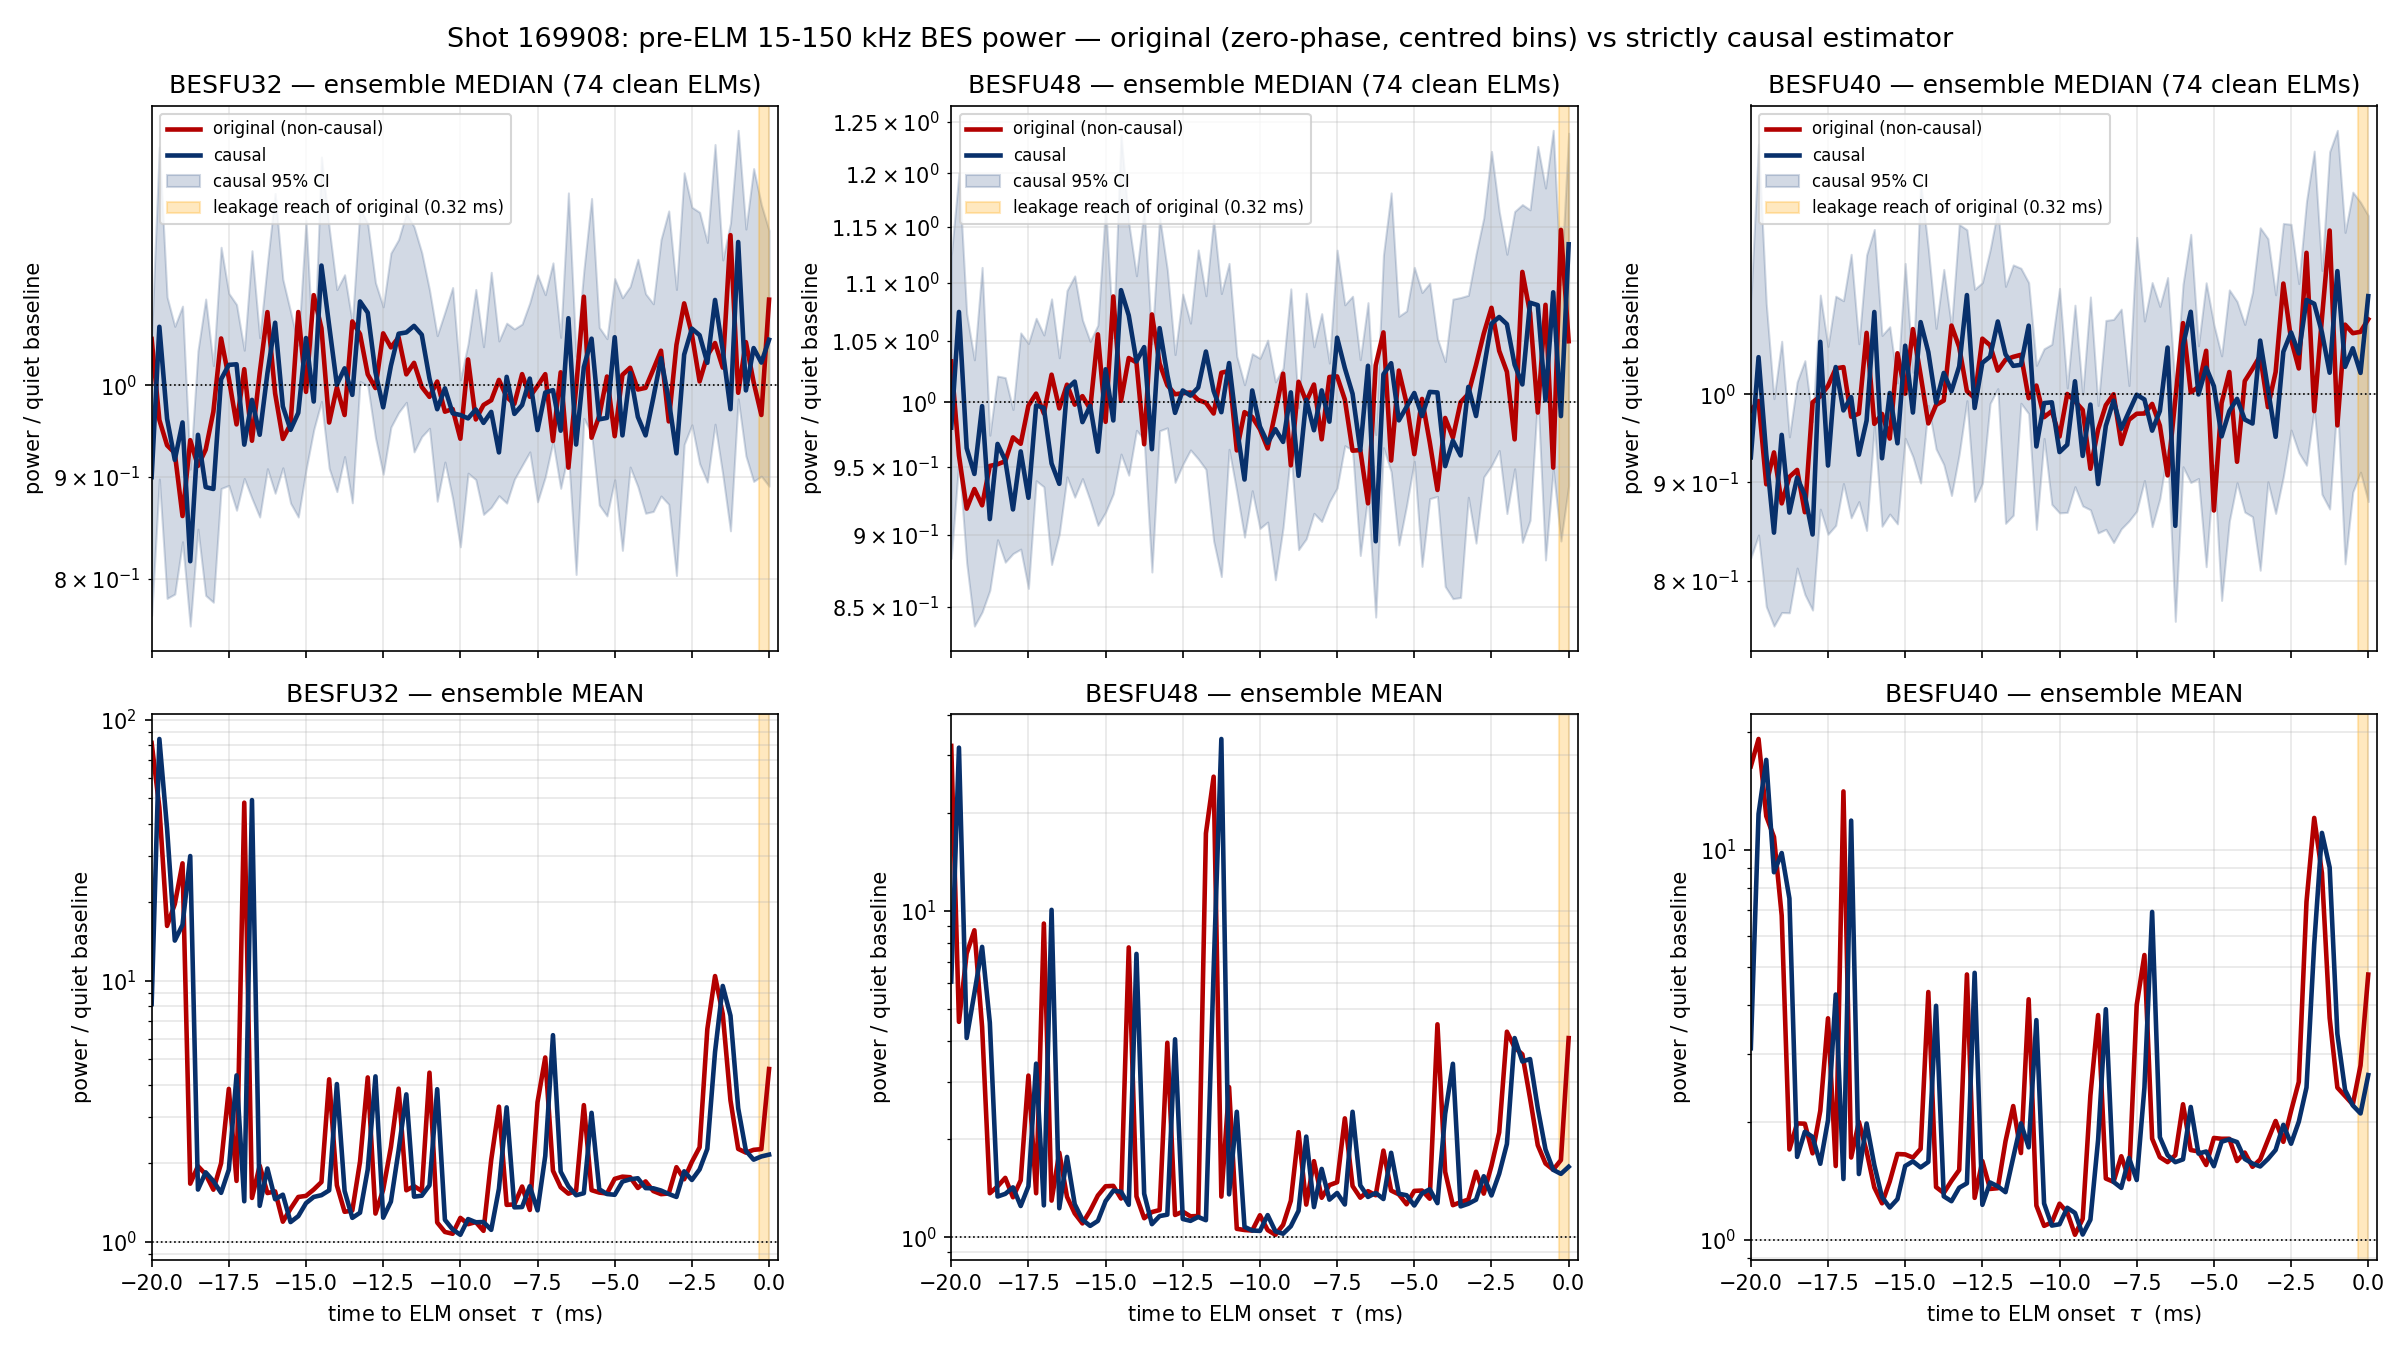

The orange band in each panel marks the 0.32 ms the original estimator could reach past each time point — visible there is how small it is next to the multi-millisecond lead times.

One methodological note: an intermediate variant using overlapping 1 ms trailing windows (rather than right-aligned 0.25 ms bins) initially showed riser counts tripling — that construction turns the duration test into an energy test and is not comparable; it was discarded in favour of the matched-bin comparison above.

**Bottom line** : the rise is real, not a leakage artifact. It survives a strictly causal estimator with zero losses — median lead **~3 ms before the labelled onset (~4.2 ms before the physical onset)** , on ~10% of channel-ELM instances, at 15–120× quiet power (up to 500×), and in at least three ELMs the elevated power demonstrably *decays before* the crash arrives.

In [8]:
%%ask
I'm worried the power estimate at each time point may be using data from after
that point — which would let the ELM itself leak backwards and create a rise
that isn't real. Redo the measurement so that the power at each time uses only
data from before it, and show the result next to the original. Does the rise
survive, and at what lead time?

## 7. What this does not establish

**Expect:** an honest list. In particular: one shot is not a population, the ELM
times are a detector's assertion rather than verified onsets, and the labelled
onset may not coincide with the physical crash.

This is a critique-and-roadmap question — but the single biggest statistical gap (no false-alarm control) can be quantified right now with the data already in hand, so I'll measure it rather than just recommend it. First, checking what scripts and caches from the previous cells are on disk to reuse.

The full 3-channel record cache (`bes_full_169908.npz`) and the causal method are already on disk. Reading the causal script so the calibration uses the *identical* statistic, plus the ELM event times for building quiet-period null windows.

Now reading the rest of the causal script (riser detection logic) and the stored riser instances so the calibration runs on the identical statistic.

Method and statistic are clear (criterion: ≥2× quiet baseline sustained ≥1 ms within τ∈[−10,0]). Writing the false-alarm calibration script — null windows drawn from mid-gap quiet stretches, same filter, same bins, same baseline normalization, same criterion.

Running the calibration against the cached 3-channel record.

The calibration exposes something important: at the per-channel level the excess is clear for one channel but marginal for two — and the ELM-level count (10 rising ELMs vs ~9 expected false) needs the null's own cross-channel correlation to interpret properly. Computing the joint null properly with a second, separate script (parametric bootstrap preserving the null's co-occurrence structure).

Both calibrations ran clean. Here is the critique, the measured numbers, and the roadmap.

## What the current result is NOT sufficient to claim

**1. It made no false-alarm statement at all — and I've now measured one.** Running the *identical* statistic (causal bins, ≥2× sustained ≥1 ms in τ∈[−10,0]) on 239 null windows taken from mid-gap quiet stretches — no ELM anywhere near them — the statistic fires on its own at **4.2–4.6% of quiet windows per channel** . Among the 74 clean ELMs that means **~9.5 of the 23 flagged instances are expected false alarms** . So the earlier "1-in-10 riser" framing overstated certainty: roughly **half** of the flagged instances are estimated real (posterior P(real|flag) ≈ 0.69 for BESFU32, ≈ 0.5 for the other two). The transient risers that "decay before onset" rule out crash-bleed but *not* false alarms — a quiet-time turbulence burst also rises and falls.

**2. "1 in 10 ELMs has a precursor" from one shot.** n = 1 discharge, one confinement regime, one pedestal state. Nothing licenses a general ELM claim, and the heavy-tailed distribution means the ensemble mean is not a stable estimator.

**3. Three channels, one radial column of an 8×8 array.** Any statement about *where* the precursor lives, or that the midplane sees it "strongest", is unsupported — that was channel selection, not measurement.

**4. Power in arbitrary units.** No beam-attenuation calibration, no δn/n, no noise-floor subtraction — the "15–120×" factors are relative to an uncalibrated quiet baseline that may itself contain electronic noise.

**5. Timing claims finer than ~1 ms.** Everything is keyed to one detector's onsets, biased +1.17 ms early vs the expert set. Lead times quoted to 0.25 ms bins are not defensible at that precision; the ±1.2 ms label uncertainty dominates the 1.5 ms short end of the lead range.

**6. A power rise is not a mode.** No wavenumber, no cross-channel phase, no growth-rate spectrum — calling it "the precursor" assumes the identification; only a broadband-amplitude excess was measured.

**7. Thresholds were chosen after seeing the data.** 2×, 1 ms, 15–150 kHz, τ∈[−10,0] were all picked in-view. No multiplicity correction, no out-of-sample test.

## What the calibration just established (new, measured)

| Test | Result |
|---|---|
| Per-channel excess vs null (binomial) | BESFU32: 10/74 vs 4.2%, **p = 0.0010** ; BESFU48: 7/74, p = 0.054; BESFU40: 6/74, p = 0.090 |
| ELMs with ≥1 rising channel | observed 10, null expectation 3.4 (95% 0–7), **p = 0.003** |
| ELMs with all 3 channels rising | observed 6, null expectation 3.1 (95% 0–7), **p = 0.089 — not significant** |
| Null joint structure | false alarms fire on all-3-channels 4.2% of the time, exactly one channel only 0.4% |

Two headline corrections to the previous cell's reading. First, **the excess count is real** : 10 rising ELMs against a false-alarm expectation of 3.4, p ≈ 0.003 — that survives proper control, and ~7 of the 10 are estimated genuine. Second, **the apparent cross-channel coherence was over-read** : my earlier independence expectation (0.08 triple events) was wrong because quiet-time bursts hit all three channels at once; against the correct joint null, 6 triple-events vs 3.1 expected is p = 0.09. Coherence across these three channels does not distinguish precursor from ordinary burstiness.


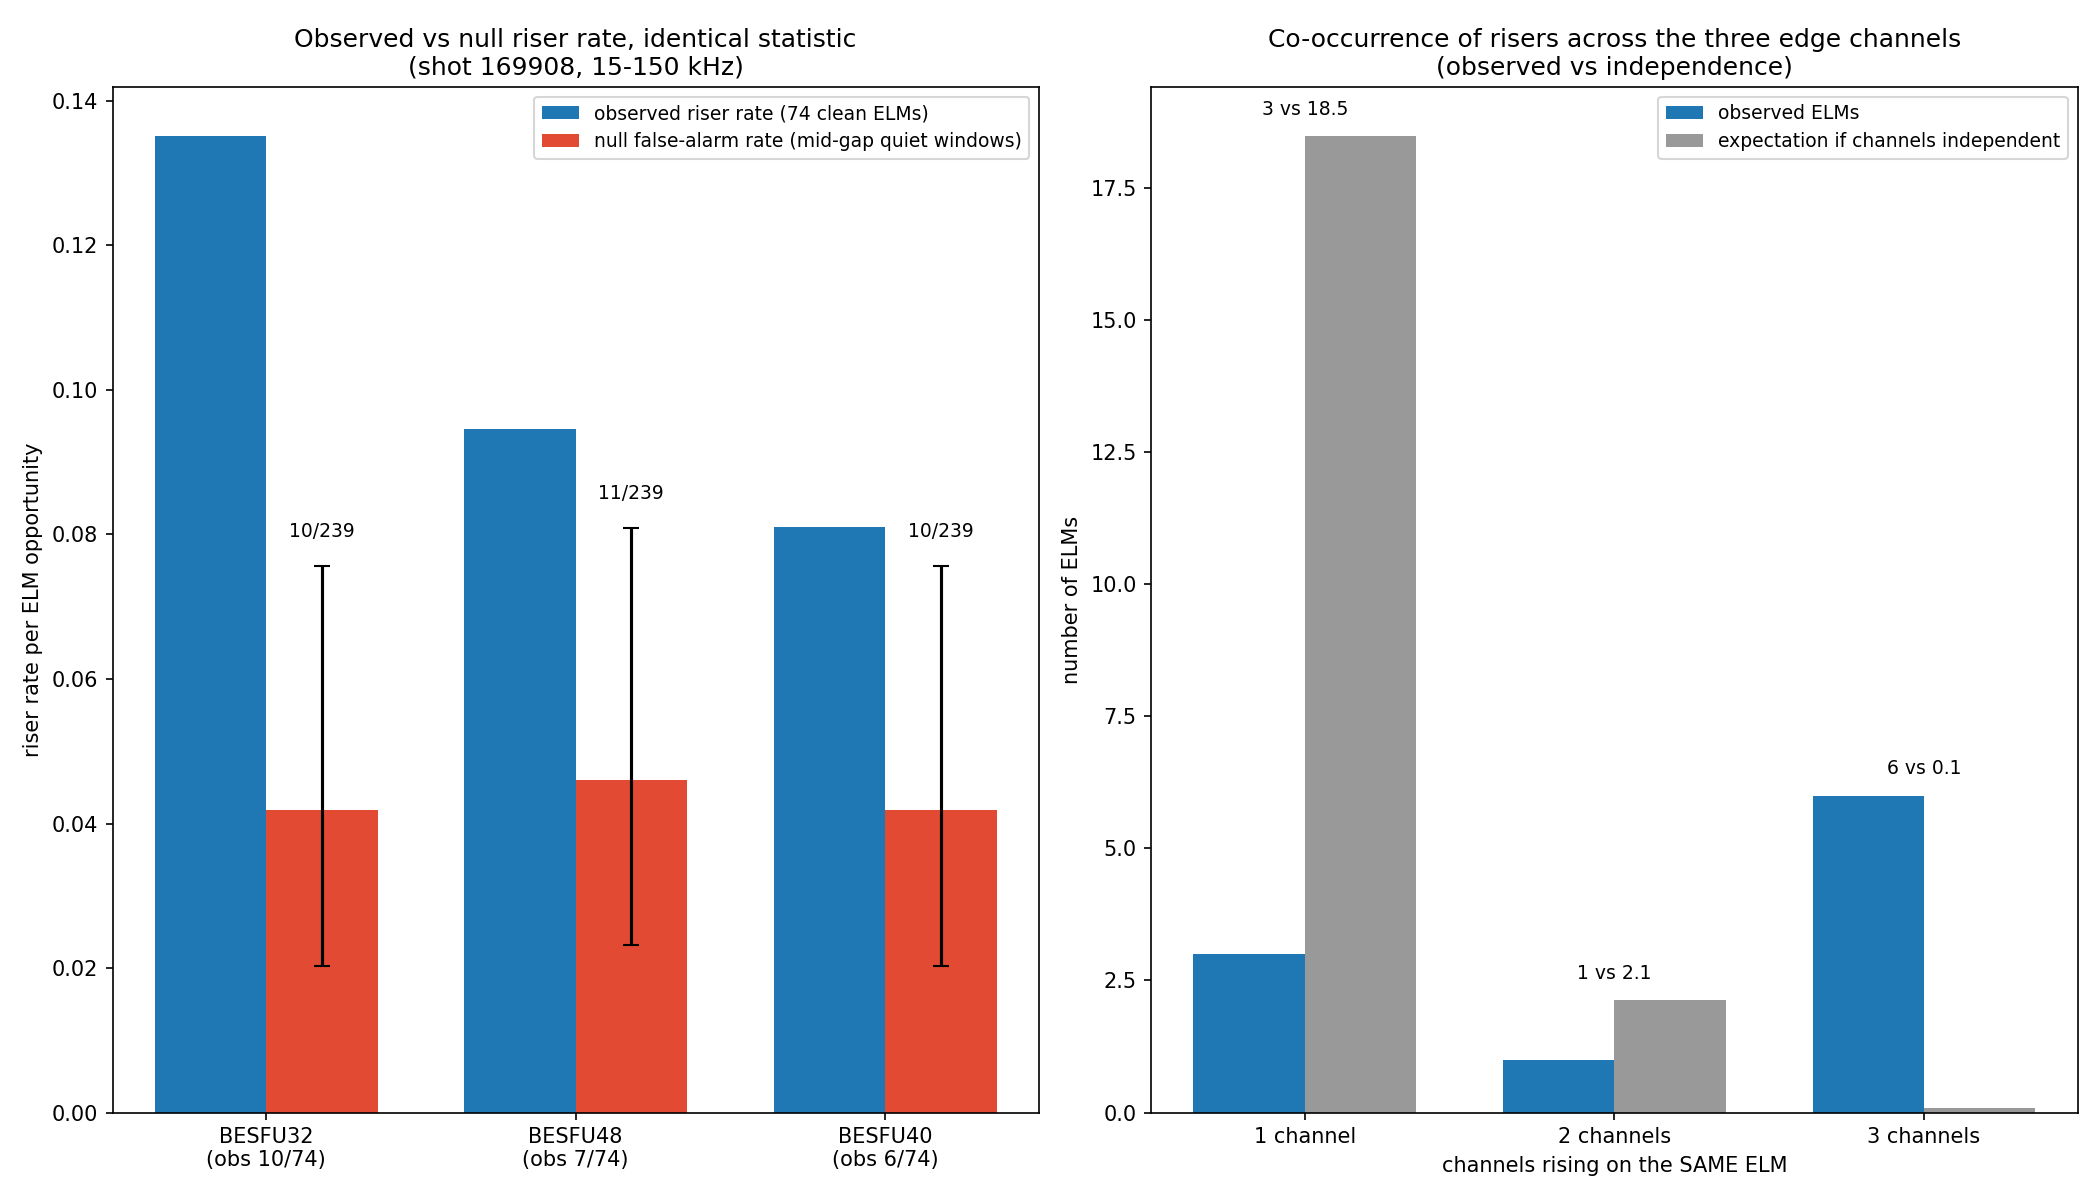

(Numbers: `bes_false_alarm_169908.json`, `bes_elm_level_significance.json`.)

## What would make it defensible — in order of leverage

1. **Lock the statistic before testing.** Pre-register threshold, band, window; report the false-alarm rate alongside every result (now cheap — the null machinery exists); correct for testing 3+ channels; quote per-instance posterior probabilities, not bare counts.
2. **Repeat across shots.** Eight more shots from cell 1 have both stored ELM labels and BES (154749, 158115, 161202, 161558, 163518, 172186, 180257, 180264). Same frozen pipeline, per-shot riser rates with binomial tests against that shot's own null, then pooled fixed-effect estimate with a shot-to-shot heterogeneity check. That converts "on this shot" into "in this dataset".
3. **Use the full array.** All 64 channels: cross-channel phase → poloidal/toroidal mode numbers, radial localization of the excess, and coherence-based detection (phase-coherent precursor vs incoherent turbulence burst) — the single strongest discriminator between a mode and enhanced turbulence.
4. **Anchor the timing.** Key to expert onsets (or define onset as the D-alpha leading edge independent of labels), report both label sets, and quote lead times with the ±1.2 ms label uncertainty folded in; drop claims at the 1–2 ms end unless they survive it.
5. **Cross-correlate with independent diagnostics.** Mirnov coils (same band) and, via the ELM-phase framework, Thomson/CER pedestal gradients around flagged ELMs: a real precursor should sit on a steeper-than-typical pedestal gradient and show magnetic correspondence.
6. **Calibrate or robustify amplitude.** Either convert to δn/n via beam geometry/attenuation, or report coherence/SNR statistics that don't depend on absolute calibration; subtract a pre-pulse noise-floor estimate from the baseline.
7. **Split-sample validation.** Freeze every parameter on half the ELMs (or one shot), evaluate once on the held-out half — the only clean answer to "the thresholds were tuned".

**Bottom line** : what survives scrutiny today is narrower than what was reported — *on shot 169908, the number of ELMs preceded by a ≥2× in-band rise significantly exceeds the false-alarm rate (10 vs 3.4, p ≈ 0.003), with roughly two-thirds of those flagged ELMs estimated genuine, strongest in BESFU32 (p = 0.001)*. Everything broader — general "ELMs have precursors", spatial localization, cross-channel coherence, sub-ms lead times — is exactly what the seven steps above would be needed to claim.

In [9]:
%%ask
What would this result NOT be sufficient to claim, and what would I need to do
to turn it into a defensible measurement?

---

## Notes

**This is not a reproduction of Joung et al.** No network is trained here. The
notebook tests the physical premise their network depends on, using a different
and independently produced set of ELM times.

**The labels are provisional.** They come from our own runs of a detector written
by others, and are expected to be superseded.

**Any outcome here is a result.** Precursors visible in ~150 curated discharges
may not survive labels made by a detector rather than by hand. The two runs in
this repository land differently — both find no rise in the average ELM, and one
goes on to find an intermittent rise on about a tenth of them — which is itself
worth knowing to anyone planning to deploy this in real time.